# **Shape Detection**

As descrições abaixo tem como objetivo reproduzir e estudar a implementação de detecção de formas geométricas apresentada no tutorial: [OpenCV Shape Detection - PyImageSearch](https://pyimagesearch.com/2016/02/08/opencv-shape-detection/).



In [127]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### **Pré processamento**

Antes de encontrar os contornos, é necessário realizar um pré-processamento da imagem para facilitar a identificação das formas.

Primeiramente, a imagem é redimensionada utilizando um fator de escala.
No código, dsize é montado a partir de **new_width** e **new_height**, calculados multiplicando a largura e a altura originais pelo fator **scale**, o que preserva a proporção da imagem. 

O fator ratio (inverso de scale) é guardado para reconverter, mais adiante, as coordenadas encontradas na imagem redimensionada de volta para a escala da imagem original.

In [128]:
image = cv2.imread("image/shapes_and_colors.jpg")

scale = 300 / image.shape[1]
resized = cv2.resize(image, None, fx=scale, fy=scale)

ratio = 1 / scale

Em seguida, a imagem, que está originalmente no formato BGR é convertida para a escala de tons de cinza. 

Depois, é aplicado um desfoque gaussiano utilizando **cv2.GaussianBlur()** para suavizar a imagem e reduzir pequenos ruídos que poderiam interferir na identificação das formas.

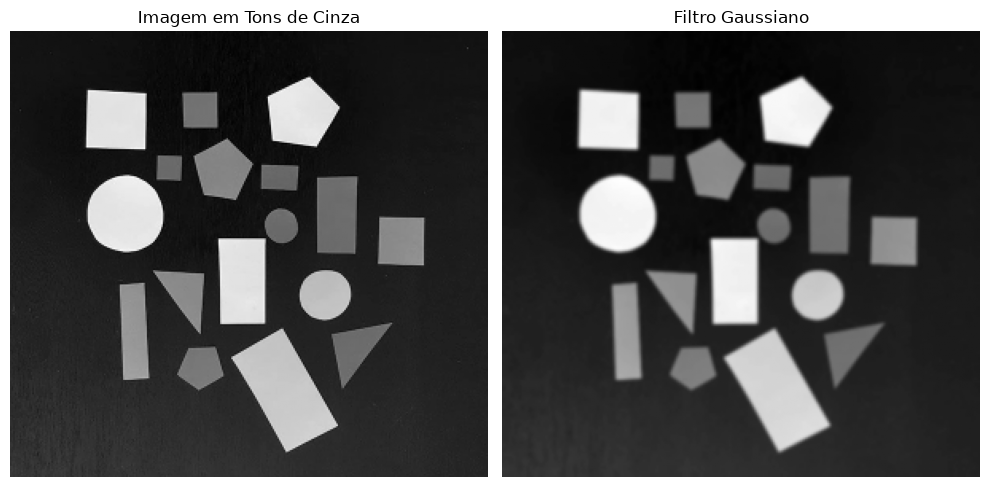

In [129]:
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

gaussian = cv2.GaussianBlur(gray, (5,5),0)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))

ax0.imshow(gray, cmap= 'gray')
ax0.set_title("Imagem em Tons de Cinza")
ax0.axis("off")

ax1.imshow(gaussian, cmap='gray')
ax1.set_title("Filtro Gaussiano")
ax1.axis("off")

plt.tight_layout()

Na sequência, é aplicado um limiar utilizando **cv2.threshold()**. Essa operação transforma a imagem em uma representação binária e dessa forma, as regiões de interesse ficam destacadas, facilitando a identificação das formas.

(np.float64(-0.5), np.float64(299.5), np.float64(279.5), np.float64(-0.5))

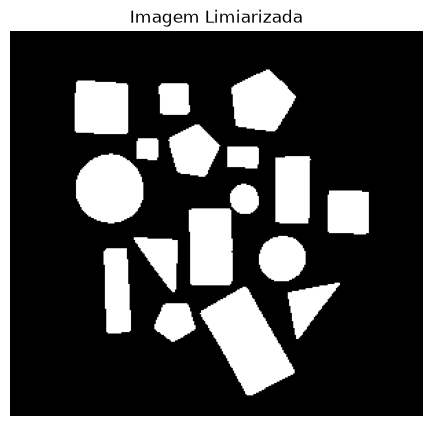

In [130]:
ret, threshold = cv2.threshold(gaussian, 60, 255, cv2.THRESH_BINARY)

fig, (ax0) = plt.subplots(1, 1, figsize=(10, 5))
ax0.imshow(threshold, cmap= 'gray')
ax0.set_title("Imagem Limiarizada")
ax0.axis("off")


### **Detecção de formas** 



O método detect(c) é responsável por analisar um **contorno c** e determinar qual forma geométrica ele representa. 

Resumidamente, a função calcula o perímetro do contorno através do arcLength(), depois simplifica esse contorno utilizando approxPolyDP() e verifica quantos vértices existem nessa aproximação. A partir da quantidade de vértices, ela classifica a forma e retorna seu nome, como "triangle", "square" ou "circle".

---

**Para calcular o perímetro de um contorno, usa-se**:

<div align="center"> cv2.arcLength(c, True) </div>

***curve***: Corresponde ao contorno que se deseja medir;

***closed***: Corresponde a um valor booleano que indica se o contorno deve ser tratado como fechado, ou seja, se o último ponto está conectado ao primeiro.

---

**Para aproximar e simplificar um contorno, usa-se:**

<div align="center"> cv2.approxPolyDP(curve, epsilon, closed) </div>


***curve***: Corresponde ao contorno original;

***epsilon***: Corresponde à tolerância da aproximação: a distância máxima permitida entre o contorno original e a aproximação. No código, é dado por 0.04 * peri, ou seja, 4% do perímetro;

***closed***: Corresponde a um valor booleano que indica se o contorno é fechado.

Um contorno real pode possuir muitos pontos mesmo quando representa uma forma simples; a função tenta representá-lo usando apenas os pontos mais importantes, gerando uma aproximação poligonal. Quanto maior o **epsilon**, maior a diferença tolerada entre o contorno original e a aproximação, e menos pontos são utilizados; quanto menor o epsilon, mais pontos são preservados.


In [131]:
class ShapeDetector:
    def __init__(self):
        pass

    def detect(self, c):
        shape = "unidentified"
        peri = cv2.arcLength(c, True) # Calcula o perímetro do contorno
        approx = cv2.approxPolyDP(c, 0.04 * peri, True) # aproxima e simplifica um contorno
        print(approx)
        print("Número de vértices:", len(approx))
        if len(approx) == 3:
            shape = "triangle"

        elif len(approx) == 4:
            (x, y, w, h) = cv2.boundingRect(approx)

            ar = w/float(h)
            shape = "square" if ar>=0.95 and ar<= 1.05 else "rectangle"

        elif len(approx) == 5:
            shape = "pentagon"

        else:
            shape = "circle"

        return shape




Para encontrar o menor retângulo alinhado aos eixos que envolve um contorno, usa-se:

<div align="center"> x, y, w, h = cv2.boundingRect(array) </div>


***array***: Corresponde ao contorno (ou pontos) a ser envolvido pelo retângulo.


A função retorna quatro valores: x e y, a posição do canto superior esquerdo do retângulo, e w e h, sua largura e altura. 

No tutorial, ela é usada apenas quando o contorno tem quatro vértices, para diferenciar quadrado de retângulo a partir do aspect ratio, ar = w / float(h):
- valores de ar entre 0.95 e 1.05 são classificados como "square"; 
- fora desse intervalo, como "rectangle". 

Essa margem existe porque, em uma imagem real, pequenas distorções podem fazer um quadrado não ter exatamente ar = 1.

### **Encontrando os contornos**

Após esse pré-processamento, é utilizada a função **cv2.findContours()** para encontrar os contornos presentes na imagem binária. Cada contorno representa a borda de uma região identificada na imagem.

**Para encontrar os contornos na imagem binária, usa-se:**

<div align="center"> contours, hierarchy = cv2.findContours(image, mode, method) </div>


***image***: Corresponde à imagem binária de 8 bits;

***mode***: Corresponde ao modo de recuperação dos contornos (aqui, cv2.RETR_EXTERNAL, que retorna apenas os contornos externos);

***method***: Corresponde ao método de aproximação (aqui, cv2.CHAIN_APPROX_SIMPLE, que armazena apenas os pontos extremos dos segmentos retos).


A função retorna contours, a lista de contornos encontrados, e hierarchy, a relação entre eles. 

In [132]:
contornos, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

Na estrutura for, os contornos encontrados são percorridos individualmente. Para cada contorno, é calculado o centroide da forma e o contorno é encaminhado ao objeto ShapeDetector, que utiliza o método detect() para identificar a forma geométrica.

Como os contornos foram extraídos da imagem redimensionada, as coordenadas do centroide e os pontos do contorno também estão nessa escala. Por isso, é necessário multiplicá-los pelo fator ratio, fazendo com que correspondam novamente às dimensões da imagem original.

**Para calcular os momentos geométricos de um contorno, usa-se:**

<div align="center"> cv2.moments(array) </div>


***array***: Corresponde ao contorno (ou a uma imagem) cujos momentos serão calculados.


A função retorna um dicionário com os momentos calculados. O momento m00 corresponde à área do contorno, enquanto m10 e m01 são usados no cálculo das coordenadas do centroide: cX = m10/m00 e cY = m01/m00. Verifica-se m00 != 0 para evitar divisão por zero em contornos degenerados (sem área).

---

**Para desenhar o contorno na imagem, usa-se:**

<div align="center"> cv2.drawContours(image, contours, contourIdx, color, thickness) </div>


***image***: Corresponde à imagem sobre a qual o contorno será desenhado;

***contours***: Corresponde à lista de contornos. No código, é passada uma lista com um único contorno já reescalado, [c_scaled];

***contourIdx***: Corresponde ao índice do contorno a ser desenhado dentro da lista. O valor -1 desenha todos os contornos da lista;

***color***: Corresponde à cor do contorno, no formato BGR;

***thickness***: Corresponde à espessura do traço, em pixels.


Depois disso é escrito na imagem o nome da forma.


In [133]:
sd = ShapeDetector()

for c in contornos:

    M = cv2.moments(c)

    if M["m00"] != 0:

        # Centro na imagem REDUZIDA
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])

        # Identifica a forma
        shape = sd.detect(c)

        # Converte centro para a imagem ORIGINAL
        cX = int(cX * ratio)
        cY = int(cY * ratio)

        # Escala o contorno para a imagem original
        c_scaled = c.astype("float") * ratio
        c_scaled = c_scaled.astype("int")

        # Desenha contorno
        cv2.drawContours(image, [c_scaled], -1, (0, 255, 0), 2)

        # Escreve o nome no centro
        cv2.putText(image,shape,(cX - 20, cY),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255, 255, 255),2)



[[[128 198]]

 [[111 199]]

 [[105 216]]

 [[117 225]]

 [[133 217]]]
Número de vértices: 5
[[[169 186]]

 [[138 205]]

 [[176 264]]

 [[206 246]]]
Número de vértices: 4
[[[239 183]]

 [[202 190]]

 [[208 223]]]
Número de vértices: 3
[[[ 70 158]]

 [[ 70 218]]

 [[ 86 218]]

 [[ 84 158]]]
Número de vértices: 4
[[[ 90 150]]

 [[119 189]]

 [[121 152]]]
Número de vértices: 3
[[[191 150]]

 [[182 159]]

 [[182 172]]

 [[202 181]]

 [[212 173]]

 [[214 160]]

 [[205 150]]]
Número de vértices: 7
[[[130 130]]

 [[131 183]]

 [[159 184]]

 [[160 130]]]
Número de vértices: 4
[[[232 116]]

 [[231 145]]

 [[260 146]]

 [[260 117]]]
Número de vértices: 4
[[[165 112]]

 [[160 118]]

 [[161 127]]

 [[167 132]]

 [[176 131]]

 [[180 126]]

 [[178 115]]]
Número de vértices: 7
[[[193  92]]

 [[193 138]]

 [[216 139]]

 [[218  93]]]
Número de vértices: 4
[[[ 72  89]]

 [[ 51 101]]

 [[ 48 121]]

 [[ 75 139]]

 [[ 92 130]]

 [[ 96 110]]]
Número de vértices: 6
[[[158  84]]

 [[158  98]]

 [[179  99]]

 [

(np.float64(-0.5), np.float64(599.5), np.float64(560.5), np.float64(-0.5))

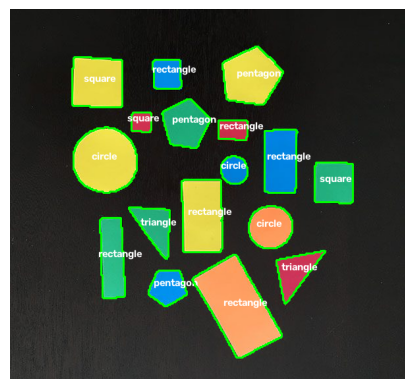

In [134]:
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2.imwrite("output/centro.png", rgb)
plt.imshow(rgb)

plt.axis('off')


### **Organizando o código em funções**

In [135]:
def pre_processing(image):

    scale = 300 / image.shape[1]

    new_width = int(image.shape[1] * scale)
    new_height = int(image.shape[0] * scale)

    resized = cv2.resize(image, (new_width, new_height))

    ratio = 1 / scale

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    gaussian = cv2.GaussianBlur(gray, (5,5), 0)

    ret, threshold = cv2.threshold(gaussian, 60, 255, cv2.THRESH_BINARY)

    return threshold, ratio

def contour(threshold, image, ratio, sd, b, g, r):
    
    contornos, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for c in contornos:

        M = cv2.moments(c)

        if M["m00"] != 0:

            # Centro na imagem REDUZIDA
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])

            # Identifica a forma
            shape = sd.detect(c)

            # Converte centro para a imagem ORIGINAL
            cX = int(cX * ratio)
            cY = int(cY * ratio)

            # Escala o contorno para a imagem original
            c_scaled = c.astype("float") * ratio
            c_scaled = c_scaled.astype("int")

            # Desenha contorno
            cv2.drawContours(image, [c_scaled], -1, (0, 255, 0), 2)

            # Escreve o nome no centro
            cv2.putText(image,shape,(cX - 20, cY),cv2.FONT_HERSHEY_SIMPLEX,0.5,(b, g, r),2)

    return image


### **Melhorias**

Uma limitação da implementação atual está na classificação das formas com mais de cinco vértices. Como a lógica utilizada considera qualquer forma que não possua 3, 4 ou 5 vértices como um círculo, formas diferentes de um círculo, como hexágonos e figuras irregulares, também acabam sendo classificadas como "circle". Abaixo um exemplo:

[[[ 15 112]]

 [[ 14 131]]

 [[ 34 133]]

 [[ 36 113]]]
Número de vértices: 4
[[[146 119]]

 [[162 133]]

 [[180 128]]

 [[170 122]]

 [[182 115]]

 [[154 106]]]
Número de vértices: 6
[[[102 106]]

 [[ 90 122]]

 [[105 135]]

 [[117 120]]]
Número de vértices: 4
[[[255 103]]

 [[246 109]]

 [[243 126]]

 [[259 138]]

 [[269 130]]

 [[271 116]]]
Número de vértices: 6
[[[62 62]]

 [[51 75]]

 [[54 91]]

 [[69 95]]

 [[74 74]]]
Número de vértices: 5
[[[207  61]]

 [[194  76]]

 [[200  79]]

 [[201  92]]

 [[214  93]]

 [[222  75]]]
Número de vértices: 6
[[[132  32]]

 [[134  54]]

 [[164  53]]]
Número de vértices: 3
[[[260  20]]

 [[252  42]]

 [[270  43]]]
Número de vértices: 3
[[[54 18]]

 [[42 25]]

 [[42 37]]

 [[57 44]]

 [[69 37]]

 [[69 25]]]
Número de vértices: 6
[[[183   1]]

 [[169  10]]

 [[168  25]]

 [[180  38]]

 [[197  39]]

 [[208  30]]

 [[210  15]]]
Número de vértices: 7


(np.float64(-0.5), np.float64(639.5), np.float64(326.5), np.float64(-0.5))

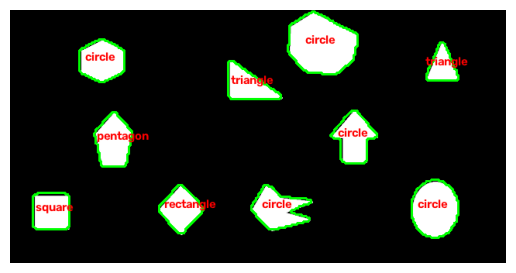

In [136]:
image2 = cv2.imread("image/formatos.png")

sd = ShapeDetector()

threshold, ratio = pre_processing(image2)

contornos2 = contour(threshold,image2,ratio,sd,0, 0, 255)

rgb = cv2.cvtColor(contornos2, cv2.COLOR_BGR2RGB)

cv2.imwrite("output/centro.png", rgb)

plt.imshow(rgb)
plt.axis('off')

Como a lógica do ShapeDetector é baseada principalmente na quantidade de vértices obtidos pelo approxPolyDP(), utilizar um único valor global de epsilon gera classificações incorretas. 

O mesmo contorno poderia ser aproximado com diferentes quantidades de vértices dependendo da sua geometria, fazendo com que círculos sejam interpretados como hexágonos ou outras formas também apresentassem seis vértices. Por isso, apenas aumentar ou diminuir o epsilon global é uma solução adequada.


**is_hexagon(approx)** é uma função auxiliar criada para diferenciar um hexágono de outras formas que também podem ser aproximadas por seis vértices. Ela recebe os seis pontos de approx, calcula o comprimento de cada lado e verifica se esses lados possuem tamanhos semelhantes.

ratio = min(sides) / max(sides): compara o menor lado com o maior. Se os lados forem semelhantes, o resultado será próximo de 1; se forem muito diferentes, será menor.

return ratio > 0.7: define que a forma será considerada um hexágono quando o menor lado tiver pelo menos 70% do tamanho do maior. Assim, o algoritmo não considera apenas os seis vértices, mas também verifica se a distribuição dos lados é compatível com um hexágono.


In [137]:
def is_hexagon(approx):

    sides = []

    for i in range(6):
        p1 = approx[i][0]
        p2 = approx[(i + 1) % 6][0]

        distance = np.linalg.norm(p2 - p1)
        sides.append(distance)

    ratio = min(sides) / max(sides)

    return ratio > 0.7



Para calcular a área delimitada por um contorno, usa-se:

<div align="center"> cv2.contourArea(contour) </div>


***contour***: Corresponde ao contorno cuja área será calculada.


É utilizada, junto do perímetro (peri), para calcular a circularidade da forma: 
- circularity = (4 * np.pi * area) / (peri ** 2).

Esse valor é 1 para um círculo perfeito e se afasta de 1 conforme a forma se torna menos circular.

Para verificar se um contorno é convexo, usa-se:

<div align="center"> cv2.isContourConvex(contour) </div>


***contour***: Corresponde ao contorno (já aproximado por approxPolyDP) a ser verificado.


A função retorna True se o contorno for convexo (nenhum de seus ângulos internos é reflexo) e False caso contrário. A função é usada para descartar como hexágono qualquer forma de seis vértices que seja côncava.



In [138]:
class ShapeDetector:
    def __init__(self):
        pass

    def detect(self, c):
        shape = "unidentified"
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.04 * peri, True)

        if len(approx) == 3:
            shape = "triangle"

        elif len(approx) == 4:
            (x, y, w, h) = cv2.boundingRect(approx)

            ar = w/float(h)
            shape = "square" if ar>=0.95 and ar<= 1.05 else "rectangle"

        elif len(approx) == 5:
            shape = "pentagon"

        elif len(approx) == 6:

            area = cv2.contourArea(c)
            
            circularity = (4 * np.pi * area) / (peri ** 2)

            if not cv2.isContourConvex(approx):
                shape = "other"

            elif circularity > 0.88:
                shape = "circle"

            elif is_hexagon(approx):
                shape = "hexagon"

            else:
                shape = "other"
        else:

            area = cv2.contourArea(c)
            circularity = (4 * np.pi * area) / (peri ** 2)

            if circularity > 0.85:
                shape = "circle"
            else:
                shape = "other"
        return shape



In [139]:
def pre_processing(image):

    scale = 300 / image.shape[1]

    new_width = int(image.shape[1] * scale)
    new_height = int(image.shape[0] * scale)

    resized = cv2.resize(image, (new_width, new_height))

    ratio = 1 / scale

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    gaussian = cv2.GaussianBlur(gray, (5,5), 0)

    ret, threshold = cv2.threshold(gaussian, 60, 255, cv2.THRESH_BINARY)

    return threshold, ratio

def contour(threshold, image, ratio, sd, b, g, r):
    
    contornos, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for c in contornos:

        M = cv2.moments(c)

        if M["m00"] != 0:

            # Centro na imagem REDUZIDA
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])

            # Identifica a forma
            shape = sd.detect(c)

            # Converte centro para a imagem ORIGINAL
            cX = int(cX * ratio)
            cY = int(cY * ratio)

            # Escala o contorno para a imagem original
            c_scaled = c.astype("float") * ratio
            c_scaled = c_scaled.astype("int")

            # Desenha contorno
            cv2.drawContours(image, [c_scaled], -1, (0, 255, 0), 2)

            # Escreve o nome no centro
            cv2.putText(image,shape,(cX - 20, cY),cv2.FONT_HERSHEY_SIMPLEX,0.5,(b, g, r),2)

    return image


(np.float64(-0.5), np.float64(639.5), np.float64(326.5), np.float64(-0.5))

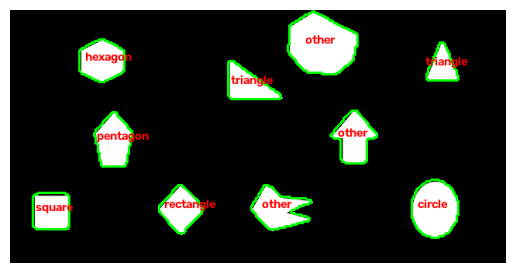

In [140]:
image2 = cv2.imread("image/formatos.png")

sd = ShapeDetector()

threshold, ratio = pre_processing(image2)

contornos2 = contour(threshold,image2,ratio,sd,0, 0, 255)

rgb = cv2.cvtColor(contornos2, cv2.COLOR_BGR2RGB)

cv2.imwrite("output/centro.png", rgb)

plt.imshow(rgb)
plt.axis('off')

Alterações na iluminação, ruído, escala ou geometria das formas podem alterar a quantidade de vértices obtidos por **approxPolyDP()**, afetando a classificação.

### **Aplicações**

A técnica de detecção de formas pode ser aplicada em sistemas de inspeção visual industrial, nos quais características geométricas dos componentes são utilizadas para verificar sua presença, posição ou conformidade.

Um exemplo seria a inspeção de  lacres e componentes circulares (ou outras formas). Nesse cenário, as etapas de pré-processamento, detecção de contornos, aproximação poligonal (approxPolyDP), cálculo de área, perímetro e circularidade podem ser utilizadas para localizar e caracterizar o componente. 

A partir dessas informações, seria possível verificar se o componente está presente, se possui formato esperado ou se apresenta alterações geométricas.

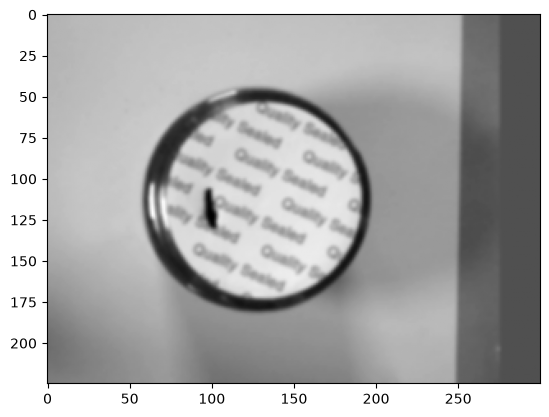

In [141]:
image_lacre = cv2.imread("image/3_fail.JPG")
scale = 300 / image_lacre.shape[1]

new_width = int(image_lacre.shape[1] * scale)
new_height = int(image_lacre.shape[0] * scale)

resized = cv2.resize(image_lacre, (new_width, new_height))
ratio = 1 / scale #converte coordenadas da imagem reduzida para a original

gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

gaussian = cv2.GaussianBlur(gray, (5,5), 0)


plt.imshow(gaussian, cmap='gray')

In [142]:
at1 = cv2.adaptiveThreshold(gaussian, 200, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

(np.float64(-0.5), np.float64(299.5), np.float64(224.5), np.float64(-0.5))

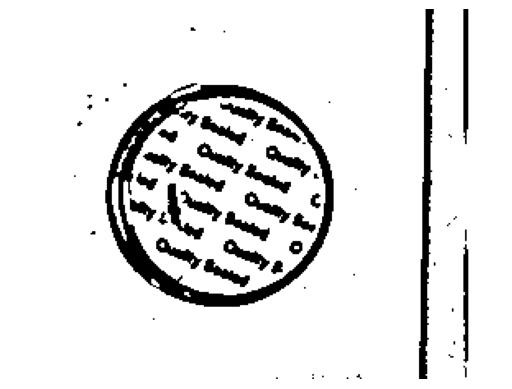

In [143]:

plt.imshow(at1, cmap='gray')

plt.axis('off')


 Inicialmente utilizava-se o RETR_EXTERNAL, mas ele estava encontrando principalmente o contorno externo da imagem. Por isso o cv2.RETR_LIST funcionou melhor pois através dele é possível analisar os contornos internos.

In [144]:
contornos, hierarquia = cv2.findContours(at1, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

In [145]:
def is_circle(c):

    area = cv2.contourArea(c)
    peri = cv2.arcLength(c, True)

    if peri == 0:
        return False

    circularity = (4 * np.pi * area) / (peri ** 2)

    #print("Área:", area, " , Circularidade:", circularity)

    return (
        circularity < 0.80
        and 10000 < area < 20000
    )

In [146]:
for c in contornos:

    if is_circle(c):
        x, y, w, h = cv2.boundingRect(c)
        
        M = cv2.moments(c)

        if M["m00"] != 0:

            c_scaled = c.astype("float") * ratio
            c_scaled = c_scaled.astype("int")

            cv2.drawContours(image_lacre,[c_scaled],-1,(0, 255, 0),2)

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

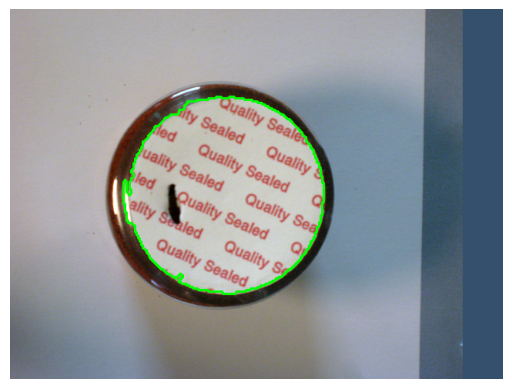

In [147]:

plt.imshow(cv2.cvtColor(image_lacre, cv2.COLOR_BGR2RGB))
plt.axis('off')

(np.float64(-0.5), np.float64(260.5), np.float64(256.5), np.float64(-0.5))

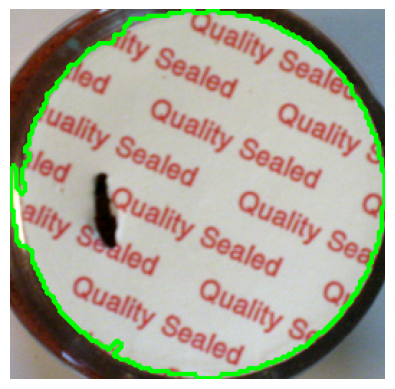

In [148]:
for c in contornos:
    if is_circle(c):
        # Converte o contorno para as coordenadas da imagem original
        c_original = (c.astype("float") * ratio).astype("int")

        # Calcula o retângulo envolvente na escala original
        x, y, w, h = cv2.boundingRect(c_original)

        # Recorta a região do lacre
        recorte = image_lacre[y:y+h, x:x+w]

        # Desenha o contorno na imagem original
        cv2.drawContours(image_lacre, [c_original], -1, (0, 255, 0), 2)

        cv2.imwrite("image/recorte_lacre.jpg", recorte)

plt.imshow(cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB))
plt.axis('off')

# **Panorama Stiching**

Dado duas imagens como 'costurá-las' juntas para criar um panorama simples?

Referência: 

- https://github.com/davidmasek/image_stitching


In [149]:
import numpy as np
import imutils
import cv2
import matplotlib.pyplot as plt

Como o algoritmo funciona?

1. Detecção de pontos-chave
O algoritmo identifica pontos visuais relevantes nas imagens, como cantos, texturas e detalhes. Em seguida, calcula descritores que representam as regiões ao redor desses pontos.

2. Correspondência entre pontos
Compara os descritores das duas imagens para encontrar pontos que provavelmente representam a mesma região da cena.

3. Estimação da homografia
Utiliza as correspondências para calcular uma matriz de transformação perspectiva.

4. Transformação e composição
Aplica a homografia para alinhar uma imagem com a outra e combina as duas em uma imagem panorâmica

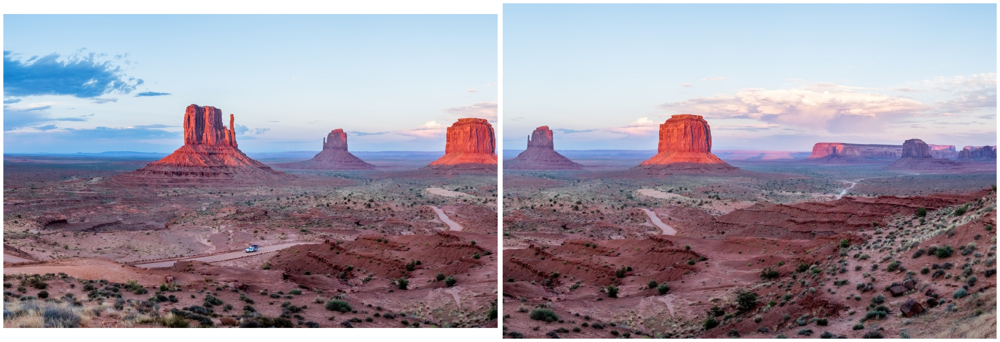

In [150]:
left = cv2.imread('image/src_left.jpg')
right = cv2.imread('image/src_right.jpg')

fig, (ax0, ax1) = plt.subplots(1, 2, figsize = (30, 20))

ax0.imshow(cv2.cvtColor(left, cv2.COLOR_BGR2RGB))
ax0.axis('off')

ax1.imshow(cv2.cvtColor(right, cv2.COLOR_BGR2RGB))
ax1.axis('off')

plt.tight_layout()

### **Detecção e correspondência de características (Feature Detection and Matching)**

Para extrair os principais recursos das imagens, utiliza-se o ORB (Oriented FAST and Rotated BRIEF) ele detecta e 'descreve' características relevantes em imagens, permitindo identificar pontos correspondentes entre diferentes imagens.

[
    ORB: é uma alternativa eficiente para SIFT ou SURF de 2011.
]

In [151]:
orb = cv2.ORB_create()

O método **detectAndCompute()** retorna duas informações principais:

- ***Keypoints*** : Identificam pontos de interesse na imagem, armazenando informações como localização, escala e orientação.

- ***Descriptors*** (descritores): Representam numericamente as regiões ao redor dos pontos-chave, permitindo comparar e encontrar correspondências entre imagens.

O ORB é projetado para lidar com variações de rotação e escala, sendo útil em tarefas como reconhecimento de objetos, alinhamento e união de imagens.

In [152]:
kp_left, des_left = orb.detectAndCompute(left, None)
kp_right, des_right = orb.detectAndCompute(right, None)

Podemos ver os pontos de interesse atrvés do **drawKeypoints**.

Para  utilizá-lo:

<div align="center">cv2.drawKeypoints(image, keypoints, outImage, color, flags)</div>

**_image_**: Corresponde à imagem de entrada;

**_keypoints_**: Corresponde à lista de pontos-chave detectados na imagem;

**_outImage_**: Corresponde à imagem de saída, onde os pontos-chave serão desenhados. Geralmente, utiliza-se None para criar uma nova imagem;

**_color_**: Corresponde à cor utilizada para desenhar os pontos-chave, no formato BGR;

**_flags_**: Corresponde às opções de desenho dos pontos-chave, permitindo definir como serão representados na imagem.

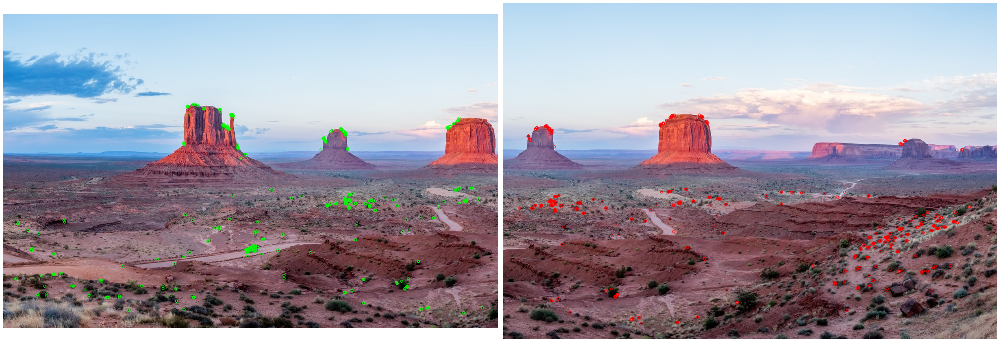

In [153]:
keypoints_drawn_left = cv2.drawKeypoints(left, kp_left, None, color=(0, 255, 0))
keypoints_drawn_right = cv2.drawKeypoints(right, kp_right, None, color=(0, 0, 255))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize = (30, 20))

ax0.imshow(cv2.cvtColor(keypoints_drawn_left, cv2.COLOR_BGR2RGB))
ax0.axis('off')

ax1.imshow(cv2.cvtColor(keypoints_drawn_right, cv2.COLOR_BGR2RGB))
ax1.axis('off')

plt.tight_layout()

Após extrair os keypoints e seus descritores, precisamos identificar quais correspondem entre as imagens. 

Para isso, utilizaremos o Brute-Force Matcher (BFMatcher) do OpenCV, que compara os descritores de uma imagem com os da outra.

Como o ORB utiliza descritores binários, utiliza-se a distância de Hamming, que conta o número de bits diferentes entre dois descritores. 

(Essa métrica é mais adequada para o ORB do que a norma L2, utilizada em descritores de valores reais)

***Quanto menor a distância de Hamming, maior a semelhança entre os descritores e, potencialmente, melhor a correspondência entre os pontos-chave.***

A função **BFMatcher** é utilizada da seguinte maneira:

<div align="center">cv2.BFMatcher(normType, crossCheck)</div>

**_normType_**: Corresponde à métrica utilizada para calcular a distância entre os descritores. Para o ORB, utiliza-se cv2.NORM_HAMMING, adequada para descritores binários;

**_crossCheck_**: Define se a correspondência deve ser mútua, ou seja, se cada descritor é o melhor correspondente do outro. Quando definido como True, ajuda a filtrar correspondências inconsistentes.


In [154]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches= bf.match(des_left, des_right)

Para visualizar as correspondências entre os pontos-chave de duas imagens, utiliza-se a função **drawMatches**:

<div align="center">cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches1to2, outImg, matchColor, flags)</div>

**_img1_**: Corresponde à primeira imagem de entrada;

**_keypoints1_**: Corresponde aos pontos-chave detectados na primeira imagem;

**_img2_**: Corresponde à segunda imagem de entrada;

**_keypoints2_**: Corresponde aos pontos-chave detectados na segunda imagem;

**_matches1to2_**: Corresponde à lista de correspondências entre os descritores das duas imagens;

**_outImg_**: Corresponde à imagem de saída que exibirá as correspondências. Geralmente, utiliza-se None para criar uma nova imagem;

**_matchColor_**: Define a cor das linhas que representam as correspondências, no formato BGR;

**_flags_**: Define as opções de desenho. A opção cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS evita a exibição de pontos-chave que não possuem correspondências.

(np.float64(-0.5), np.float64(2419.5), np.float64(795.5), np.float64(-0.5))

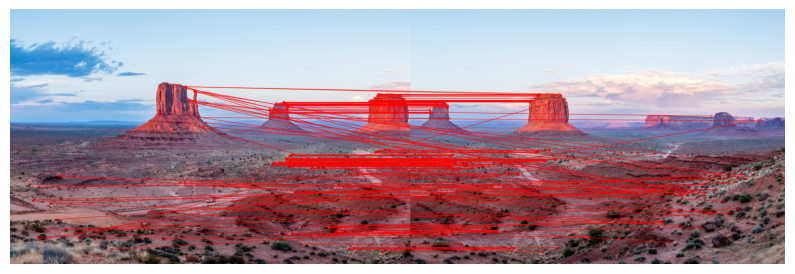

In [155]:
matches_draw= cv2.drawMatches(left, kp_left, right, kp_right, matches, None, matchColor=(0, 0, 255),
                               flags = cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(matches_draw, cv2.COLOR_BGR2RGB))
plt.axis('off')

Selecionaremos as 10 melhores correspondências entre as duas imagens e exibiremos os pontos correspondentes conectados por linhas

(np.float64(-0.5), np.float64(2419.5), np.float64(795.5), np.float64(-0.5))

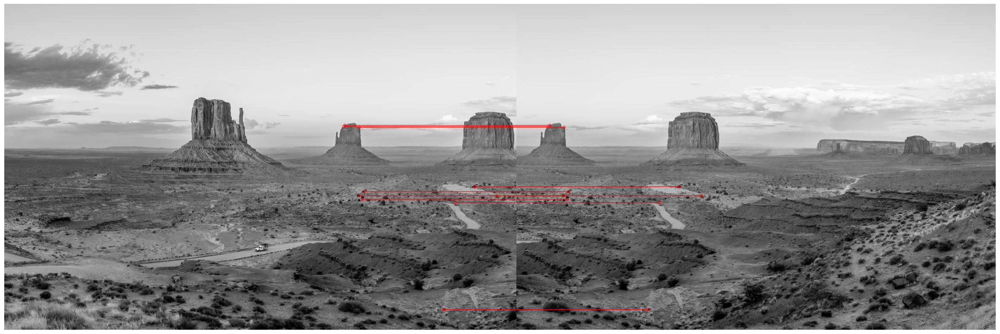

In [156]:
limit = 10
best = sorted(matches, key = lambda x:x.distance)[:limit]

left_gray = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY)

best_matches_draw = cv2.drawMatches(left_gray, kp_left, right_gray, kp_right, best, None, matchColor=(255,0,0),
                                      flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(30, 20))
plt.imshow(best_matches_draw, cmap='gray')
plt.axis('off')

### **Transformação de perspectiva e finalização**

A partir das melhores correspondências entre os descritores, vamos extrair as coordenadas dos pontos-chave nas imagens esquerda e direita. Essas coordenadas serão utilizadas posteriormente para calcular a matriz de homografia, que permite alinhar as imagens para a criação do panorama.

In [157]:
left_pts = []
right_pts = []

for m in best:
    l = kp_left[m.queryIdx].pt
    r = kp_right[m.trainIdx].pt
    left_pts.append(l)
    right_pts.append(r)

A **homografia** é uma transformação matemática que permite mapear pontos de uma imagem para outra, considerando mudanças de perspectiva, rotação e translação, desde que a relação entre as imagens possa ser representada por uma transformação projetiva.
No image stitching, ela é utilizada para alinhar duas imagens que possuem uma região em comum, permitindo combiná-las para formar um panorama.


Para calcular a matriz de homografia entre duas imagens, utiliza-se a função **findHomography**:

<div align="center">cv2.findHomography(srcPoints, dstPoints, method)</div>

**_srcPoints_**: Corresponde às coordenadas dos pontos de origem, neste caso, os pontos da imagem direita (right_pts);

**_dstPoints_**: Corresponde às coordenadas dos pontos de destino, neste caso, os pontos correspondentes da imagem esquerda (left_pts);

**_method_**: Define o método utilizado para estimar a homografia. Quando omitido, utiliza-se o método padrão, sem rejeição de correspondências inconsistentes.

A função retorna a matriz de homografia **M**, que representa a transformação projetiva necessária para mapear os pontos da imagem direita para a imagem esquerda, e uma máscara que indica quais correspondências foram consideradas *inliers*.

O símbolo `_` é utilizado para ignorar a máscara retornada pela função.

In [158]:
M, _ = cv2.findHomography(np.float32(right_pts), np.float32(left_pts))


Aqui são definidas as dimensões da imagem resultante, somando as larguras e selecionando a maior altura entre as duas imagens. Em seguida, a função cv2.warpPerspective() aplica a matriz de homografia à imagem direita, ajustando sua perspectiva para alinhá-la à imagem esquerda.

(np.float64(-0.5), np.float64(2419.5), np.float64(795.5), np.float64(-0.5))

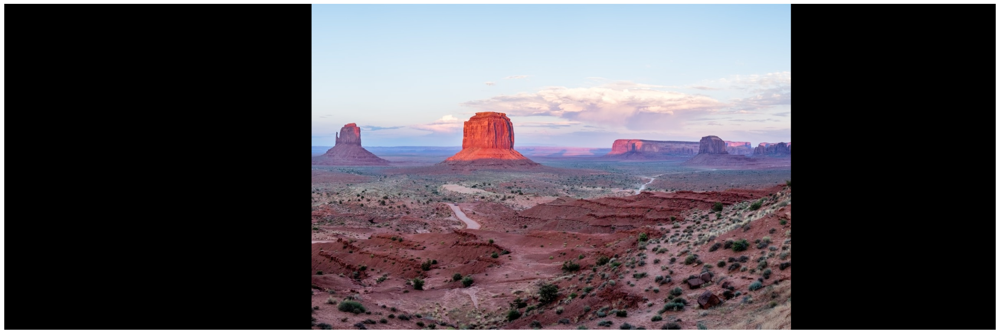

In [159]:
dim_x = left.shape[1] + right.shape[1]
dim_y = max(left.shape[0], right.shape[0])
dim = (dim_x, dim_y)

warped = cv2.warpPerspective(right, M, dim)

plt.figure(figsize=(30, 20))
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.axis('off')

Abaixo é criada uma cópia da imagem direita transformada (warped), que servirá como base para o panorama. Em seguida, sobrepõe a imagem esquerda no canto superior esquerdo, substituindo os pixels dessa região. Depois, recorta o resultado para manter apenas os primeiros 1920 pixels de largura e, por fim, exibe a imagem combinada com as cores corrigidas para o formato RGB.

(np.float64(-0.5), np.float64(1919.5), np.float64(795.5), np.float64(-0.5))

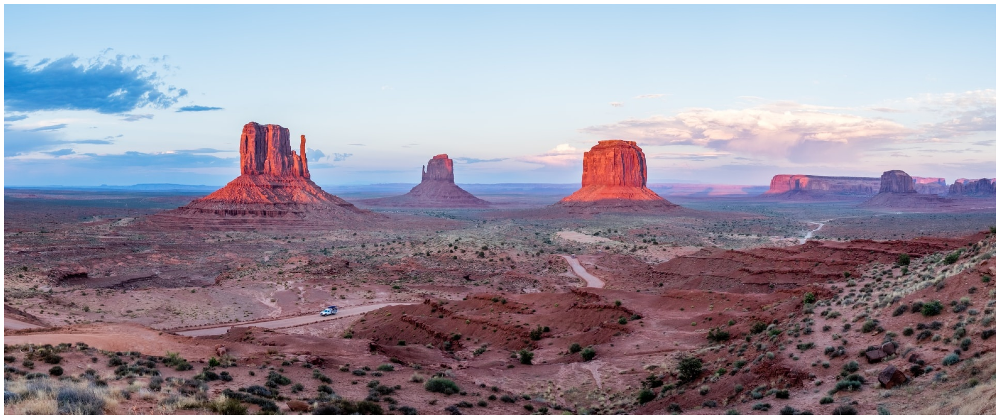

In [160]:
comb = warped.copy()
# combine the two images
comb[0:left.shape[0],0:left.shape[1]] = left
# crop
r_crop = 1920
comb = comb[:, :r_crop]

plt.figure(figsize=(30, 20))
plt.imshow(cv2.cvtColor(comb, cv2.COLOR_BGR2RGB))
plt.axis('off')